In [100]:
import os
os.listdir()


['.ipynb_checkpoints',
 'app.py',
 'Fake.csv',
 'model.pkl',
 'train_model.py',
 'True.csv',
 'Untitled.ipynb',
 'Untitled1.ipynb',
 'vectorizer.pkl']

# importing all our libraries 
# downloading stopwords to extract stopword dataset for sentiment analysis

In [101]:
import pandas as pd
import numpy as np
import nltk
import string
import pickle

from nltk.corpus import stopwords
from textblob import TextBlob

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [102]:
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

 

In [103]:
fake["label"] = 0
real["label"] = 1

                         

# imported our data labelled our data and joined both our sets 

In [104]:
df = pd.concat([fake, real])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()



(44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


# basic EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


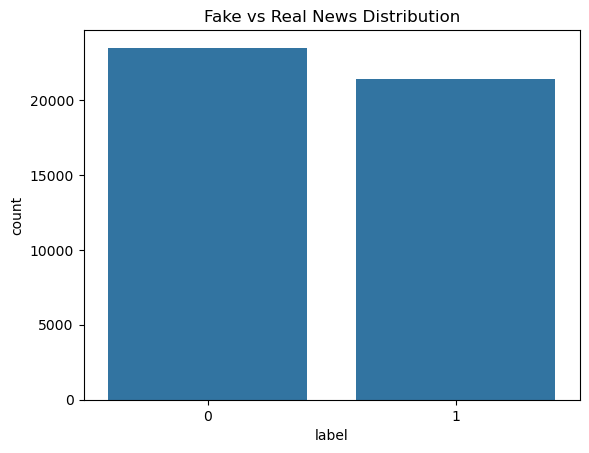

In [105]:
df.columns
df.info()
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Distribution")
plt.show()
  

# feature creation

In [116]:
df["num_exclamation"] = df["title"].apply(lambda x: x.count("!"))

df["title_length"] = df["title"].apply(len)

# creating a fucn tht converts text into blob objs analysis emotions and chooses polarity

In [117]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df["sentiment"] = df["title"].apply(get_sentiment)


# emotinal words dictionary

In [118]:
emotional_words = ["shocking","breaking","unbelievable","amazing","secret","scandal","danger"]

def count_emotional_words(text):

    words = text.lower().split()
    count = 0
    
    for word in words:
        if word in emotional_words:
            count += 1
            
    return count

df["emotional_words"] = df["title"].apply(count_emotional_words)



# cleaning our texts 

In [119]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    cleaned_words = []

    for word in words:
        if word not in stop_words:
            cleaned_words.append(word)

    return " ".join(cleaned_words) 

In [138]:
df["clean_text"] = df["text"].apply(clean_text)
X_text = (df["title"] + " " + df["clean_text"]).apply(clean_text)


# feature addition

In [139]:
X_text = df["clean_text"]

extra_features = df[[
    "title_length",
    "num_exclamation",
    "sentiment",
    "emotional_words"
]]

y = df["label"]


# train test split 

In [140]:
X_train_text, X_test_text, X_train_extra, X_test_extra, y_train, y_test = train_test_split(
    X_text,
    extra_features,
    y,
    test_size=0.2,
    random_state=42
)


# TF-ID vectorisation

In [141]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)


# converting it into horizontal stack

In [142]:
from scipy.sparse import hstack

X_train = hstack((X_train_vec, np.array(X_train_extra)))
X_test = hstack((X_test_vec, np.array(X_test_extra)))


# taining out model via logistic regg

In [143]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [144]:
y_pred = model.predict(X_test)


#accuracy score cal

In [145]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.989086859688196


In [146]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4710
           1       0.98      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



#confusion matrix

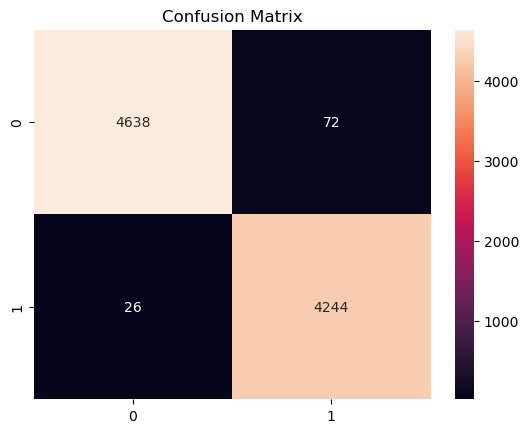

In [147]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()


In [151]:
pickle.dump(model, open("../model.pkl", "wb"))
pickle.dump(vectorizer, open("../vectorizer.pkl", "wb"))


#testing our custom news for site

In [149]:
def predict_news(title, text):

    title_len = len(title)
    exclamation = title.count("!")
    sentiment = TextBlob(title).sentiment.polarity
    emotional = count_emotional_words(title)

    cleaned = clean_text(text)

    text_vec = vectorizer.transform([cleaned])

    features = np.array([[title_len, exclamation, sentiment, emotional]])

    X_input = hstack((text_vec, features))

    prediction = model.predict(X_input)[0]

    if prediction == 0:
        print("Fake News")
    else:
        print("Real News")


In [150]:
predict_news(
    "BREAKING!!! Secret government scandal exposed",
    "A shocking report claims hidden corruption..."
)


Fake News
